# Catch22 Feature Selection: Part A — Statistical Prefiltering
This notebook reproduces the statistical prefiltering stage of the Catch22 pipeline [Lubba et al., 2019](https://doi.org/10.1007/s10618-019-00647-x) on the UCR classification benchmark. 

*It's Part 1 of a two-part series exploring systematic feature selection for time-series anomaly detection — see the accompanying LinkedIn post[ADD post link] for the motivation from industrial BESS data.*

Pipeline overview. Catch22 reduces ~7,000 hctsa features to a canonical 22 in three stages:

1. Statistical prefiltering: Remove features with no real discriminative power — those whose accuracy arises from chance label alignment on finite samples. (~4000–6000 features remain)
2. Performance-based filtering: Keep top performers that achieve decent accuracy across datasets. (~700–900 features remain)
3. Redundancy minimization via clustering: 700-900 features are still a computationally expensive set for real world usecases. Many top performers measure similar time-series characteristics, so their performance patterns across datasets are correlated. This stage clusters features by performance similarity and selects the best representative from each cluster, yielding a compact canonical set (~20–22 features).


**This notebook covers stage 1. Stages 2–3 are in [Part B](03b_c22_feat_select.ipynb).**

**Goals**
- Learn fundamentals of feature selection - for classification task, *by deconstructing the pipeline of C22 paper [ADD paper ref]* 
   - so in next steps - to be able to **replicate the pipeline for anomaly detection**. *Pre-computed feature based models make it easier to reason about the model results - more interpretability which translates to more trust from operators/engineers to make results actionable*

**Non-Goals**
- Creating a python module 
- to run the pipeline on a different feature set or new datasets

# Imports

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
from core import feat_selection as fs

## Data Prep: UCR Clasification data
- load pre-saved features (with raw data characterizing features removed)
  - *C22 Paper*: "We performed an initial filtering of all 7658 hctsa features based on their characteristics and general applicability. Because the vast majority of time se-ries in the UCR/UEA repository arez-score normalized1, we first removed the766 features that are sensitive to the mean and variance of the distribution ofvalues in a time series based on keywords assigned through previouswork [15],resulting in a set of 6892 features"
  - I did this filtering by reading the mat files in python and finding the op matrix, which is a meta-data matrix for the feature definitions. 
  - Open question: does prefiltering even matter? can the rest of the pipeline remove the raw features. It definitely helps in reducing computation time. 
- these features are missing two autocorrelation related features - which can be computed from raw time series (tabled for now). Not sure if its bcz the dataset provided was froma different version of matlab or code itself. 
  - *C22 paper*: "Features were calculated in Matlab 2017a (a product of The MathWorks, Natick, MA) using hctsa v0.97."

Source Data: [Paper code and data](https://github.com/chlubba/op_importance?tab=readme-ov-file#computing-the-hctsa-matrices) 

Refer to Data load section of `rough_drafts/03old_feature_selection.ipynb`

*Note* - The original source code relies on numpy arrays and is difficult to follow. This implementation is a simplified pandas-based version of the paper's methodology. It is presented here as a deconstructed steps - to understand the methodology. Packaging it into a pipeline module is a future step.


In [2]:
all_tasks = pd.read_parquet(
    Path("../datasets/catch_22/checkpoints/ucr_hctsa_raw_removed.parquet"),
)
print(all_tasks["dataset_name"].nunique())
print(all_tasks.shape)

93
(147198, 6894)


Note: The rest of this notebook runs on a sampled dataset to illustrate Part A of the pipeline (Statistical Prefiltering is computationally expensive). The main pipeline step — performance-based clustering — is presented on the full dataset in *Part B: Performance Based Feature Selection.*

In [3]:
sample_datasets = fs.sample_imbalanced_datasets(all_tasks)
sample_tasks = all_tasks[all_tasks["dataset_name"].isin(sample_datasets.index)]
sample_tasks.shape


57 datasets with minority class <= 30% of samples


(6127, 6894)

### Normalize Features: MinMax
- *C22 paper:* For each dataset, each feature was linearly rescaled to the unit interval. 
- Features with zero range (constant across all time series in a dataset) become NaN

In [4]:
tasks_n = fs.normalize_features(sample_tasks)
print(f"Shape: {tasks_n.shape}")

Shape: (6127, 6893)


## Prefiltering - Remove Invalid Valued Features
- *C22 paper*: Algorithms that produced special-valued outputs on at least one time series,
  in more than 80% of our datasets were excluded: a total of 2101 features

In [5]:
tasks_n_pf = fs.filter_invalid_features(tasks_n.reset_index()) 
tasks_n_pf.shape
# all_tasks_n_pf.to_parquet(Path("../datasets/catch_22/checkpoints/ucr_tasks_feat_norm.parquet"))

Median: 100.0%
Worst:  40.0%
≥99%:   74.7% of survivors
Catch22 In survivors: 20/22
Missing from survivors: []
Not in feature set at all: []


(6127, 6338)

# Methodology Overview

Refer to Fig. 1 in the paper. The rest of this notebook focuses on Statistical Prefiltering. Though it only rejects ~145 features (Table S1), it's an important step for removing features with no real discriminative signal — those whose accuracy arises from chance label alignment on finite samples.

## Performance Scoring

**Accuracy estimation**

C22 uses class-balanced accuracy to handle label imbalance within datasets: without it, a feature could score well just by predicting the majority class. 

$a_{i,j}(y, \hat{y}, w) = \frac{1}{\sum_{l=1}^{N_{\text{TS}}} w_l} \sum_{l=1}^{N_{\text{TS}}} \mathbf{1}(\hat{y}_l = y_l), w_l$

where $w_l = 1 / \sum_{m=1}^{N_{\text{TS}}} \mathbf{1}(y_m = y_l)$ down-weights samples from majority classes, and $\mathbf{1}(\cdot)$ is the indicator function.

Accuracy is estimated via stratified CV. The fold count adapts per task — capped at 10, but reduced when the rarest class has fewer than 10 samples, so every fold still sees at least one example of every class:

$N_{\text{CV}} = \min \left\lbrace 10,\; \max \left[ 2,\; \min_{k=1}^{N_c} \sum_{l=1}^{N_{\text{TS}}} \mathbf{1}(y_l = k) \right] \right\rbrace$


In [6]:
nfolds = fs.num_of_folds(tasks_n_pf)
perf_scores = fs.calc_per_feat_score(tasks_n_pf, nfolds)


[1/5] dname='AALTDChallenge'
[2/5] dname='CinCECGtorso'
[3/5] dname='ECGMeditation'
[4/5] dname='MiddlePhalanxOutlineAgeGroup'
[5/5] dname='NonInvasiveFetalECGThorax1'


### Dataset complexity 

- Some datasets are intrinsically easier to classify than others, which shifts the per-task distribution of feature accuracies.
- Normalizing each feature's accuracy by the mean accuracy across all features on that task gives a relative performance measure. This lets us ask whether a feature is consistently better than its peers across tasks, preventing the pipeline from favoring features that only look good on easy datasets.
 

In [7]:
fig = fs.plot_score_densities_per_dataset(perf_scores)
fig.show()

### Combined score - C22 features in top performers
- Scores are normalized within the dataset to normalize against the dataset complexity.
- And then combined per feature by taking mean across all the tasks. Combined accuracy gives a single measure of comparison.

In [8]:
perf_scores_n, perf_scores_n_c = fs.normalize_and_combine_perf_scores(perf_scores)
perf_scores_n_c.head()

level_1                1.226445
DN_HistogramMode_5     1.576825
DN_HistogramMode_10    1.777395
DN_HistogramMode_20    1.755513
maximum                1.249617
dtype: float64

*Note* C22 features should be among top performers, otherwise they will get removed in stage 2. 

In [9]:
fig = fs.plot_combined_accuracy(perf_scores_n_c)
fig.show()

# Stage 1: Statistical filtering: random performant features
*C22 paper:*  "Given the size and diversity of features in hctsa, we first wanted to deter-
mine whether some features exhibited performance consistent with chance on
this set of classification tasks. 
To estimate a p-value for each feature on each classification task, 
1. we generated *null accuracy distributions*, as i,j (superscript
s incidating ‘shuffeled’), using a permutation-based procedure that involved
1000 repeats of the classification procedure using randomly shuffled class la-
bels, shown in Fig. 1A. From visual inspection, the null distributions were
mostly unimodal and approximately normally distributed and, as expected,
had higher variance on datasets with fewer time series. 
2. Accordingly, we estimated a p-value for each feature-task combination by fitting a Gaussian prob-
ability distribution to the null accuracy distributions, as i,j , as the probability
of the shuffled accuracy being higher than the observed accuracy."


## Null Distribution

In [10]:
# Features from Table S1 in paper which lists the features removed in statistical prefiltering stage
random_perf_features = pd.read_csv(
      Path('../datasets/catch_22/checkpoints/catch22_insignificant_features_S1.txt'),                                                                                                                                                   
      comment='#',
      header=None,                                                                                                                                                                                        
      names=['p_value', 'feature_name']                                                                                                                                                                   
  )
                                                                                                                                                                                                          
# Get the list of features that performed no better than random
random_feature_names = random_perf_features['feature_name'].values

- features are sampled to illustrate the steps

In [11]:
sampled_features = fs.CATCH22 + list(random_feature_names[:50])
sampled_features = [col for col in tasks_n_pf.columns if col in sampled_features] # make sure that the feature is present in the dataset

In [ ]:
# this was run previously and null_scores were stored, commented out as it takes too long to run, 
# null_scores = fs.calc_score_null_dist(tasks_n_pf, nfolds, features=sampled_features, n_permutations=200)
# null_scores


In [13]:
# storing the null scores - as this is an expensive op
# import pickle
# with open(Path("../datasets/catch_22/checkpoints/sampled_null_scores.pkl"), "wb") as f:
#     pickle.dump(null_scores, f)
import pickle

with open(Path("../datasets/catch_22/checkpoints/sampled_null_scores.pkl"), "rb") as f:
    null_scores = pickle.load(f)

In [14]:
perf_scores[sampled_features].head()

,DN_HistogramMode_5,DN_HistogramMode_10,CO_HistogramAMI_even_2_5,IN_AutoMutualInfoStats_40_gaussian_fmmi,CO_trev_1_num,SB_TransitionMatrix_3ac_sumdiagcov,PD_PeriodicityWang_th0.01,CO_Embed2_Dist_tau_d_expfit_meandiff,FC_LocalSimple_mean1_tauresrat,FC_LocalSimple_mean3_stderr,...,NL_MS_nlpe_fnn_mi_ac3n,NL_MS_nlpe_fnn_mi_acmnd0,MS_shannon_2_1t10_maxent,MS_shannon_3_1t10_maxent,MS_shannon_3_1t10_stdent,MS_shannon_4_1t10_maxent,MS_shannon_4_1t10_stdent,MF_armax_3_1_05_1_lastimprovement,MF_armax_3_1_05_1_ac3n,MD_hrv_classic_pnn40
dataset_name,,,,,,,,,,,,,,,,,,,,,
AALTDChallenge,0.316667,0.302381,0.264286,0.383333,0.155556,0.280952,0.270635,0.218254,0.257143,0.348413,...,0.161905,0.156349,0.146032,0.149206,0.194444,0.133333,0.192063,0.180952,0.175397,0.300000
CinCECGtorso,0.504187,0.521468,0.468532,0.489107,0.432480,0.436290,0.760496,0.614524,0.454563,0.524623,...,0.338810,0.335179,0.265159,0.243115,0.294365,0.255099,0.260516,0.258968,0.432698,0.488552
ECGMeditation,0.583333,0.291667,0.500000,0.520833,0.541667,0.479167,0.645833,0.541667,0.604167,0.437500,...,0.333333,0.229167,0.291667,0.458333,0.437500,0.437500,0.312500,0.479167,0.541667,0.312500
MiddlePhalanxOutlineAgeGroup,0.579357,0.650922,0.477191,0.563558,0.567826,0.630588,0.363752,0.588352,0.664407,0.580083,...,0.327366,0.340524,0.383351,0.485305,0.428842,0.375203,0.378725,0.357190,0.360960,0.607063
NonInvasiveFetalECGThorax1,0.170751,0.283484,0.202476,0.118454,0.097159,0.131927,0.130479,0.252046,0.180333,0.118761,...,0.027540,0.030023,0.026563,0.023554,0.021418,0.024987,0.026243,0.025581,0.040675,0.122376


In [15]:

p_values = fs.calc_p_values(perf_scores[sampled_features], null_scores)


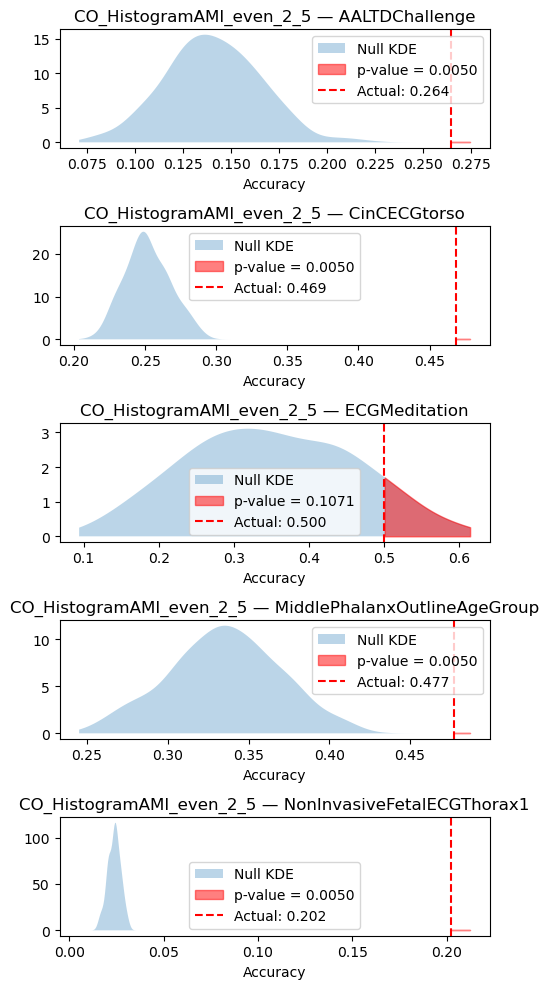

In [16]:

fig = fs.plot_null_distribution(sampled_features[2], perf_scores, null_scores, p_values)

*NOTE* `CO_HistogramAMI_even_2_5` seems to have some indicative power(for the label) for 4 out of 5 sampled datasets. 

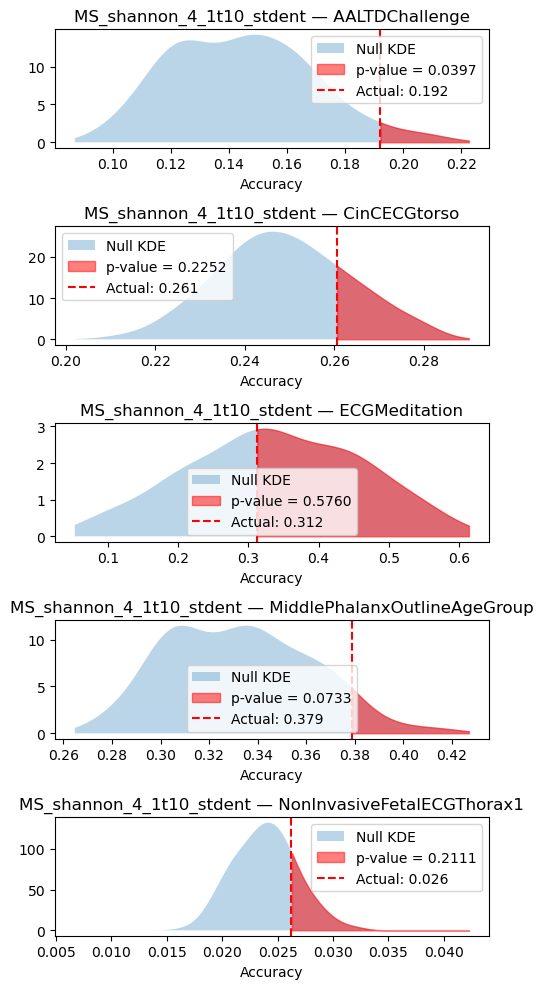

In [17]:
fig = fs.plot_null_distribution(sampled_features[-4], perf_scores, null_scores, p_values)

*NOTE* `MS_shannon_4_lt10_stdent` even with decent accuracy score of 38% in  MiddlePhalanxOutlienAgeGroup and is very close in performance to a random classifier. 

## Fisher Test
 We ran ran the same statistical test (e.g., "is feature X useful for classification?") across many independent tasks. Now you have a collection of p-values for the same feature:

  Feature "mean_abs_change":
    Task 1 → p = 0.03
    Task 2 → p = 0.12
    Task 3 → p = 0.08
    Task 4 → p = 0.45
    ...
Fisher test is used to combine p-values of a given feature (across all tasks).

The core intuition:*
- Permuting the labels of the dataset breaks the relationship between the feature and labels. If a feature is useless, then even after permutation, it can give high score by random chance. So $P(X> actual\_score)$ can be arbirtrarily high, where X is distribution of scores under null hypothesis. 
- Null Hypothesis: Feature has no meaninful relationship with the labels, which implies that $p$-value(= $P(X > actual\_score)$) can be arbitrarily high - i.e. $p$ follows Unif[0,1] distribution (since probability min=0 and max=1).
-  That means $-log(p)$ follows an exponential distribution, and $-2 * log(p)$ follows a chi-squared distribution. 
-  We can test the null hypothesis for each task individually, but here we want to make a decision based on scores across the tasks whether to keep the features. 
- Fisher's Test combines the p-values using the fact that *sum of independent* chi-squared variables gives yet another chi-square variable. 
- So for k independent tests: $X² = -2 * \sum_{i=1}^{M} log(pᵢ)$ where $M$ is total number of classification tasks. This follows a chi-squared distribution with 2k degrees of freedom under the null.
- Note here the classification tasks are all different domains, so its safe to assume independence across tasks(i.e. datasets). 


  Why it works intuitively

  - Small p-values → large -log(p) → inflates the sum
  - If many tasks give small p-values, the sum becomes improbably large under the null
  - Even if no single task is "significant" alone, consistent evidence across tasks accumulates

In [18]:
p_values

,DN_HistogramMode_5,DN_HistogramMode_10,CO_HistogramAMI_even_2_5,IN_AutoMutualInfoStats_40_gaussian_fmmi,CO_trev_1_num,SB_TransitionMatrix_3ac_sumdiagcov,PD_PeriodicityWang_th0.01,CO_Embed2_Dist_tau_d_expfit_meandiff,FC_LocalSimple_mean1_tauresrat,FC_LocalSimple_mean3_stderr,...,NL_MS_nlpe_fnn_mi_ac3n,NL_MS_nlpe_fnn_mi_acmnd0,MS_shannon_2_1t10_maxent,MS_shannon_3_1t10_maxent,MS_shannon_3_1t10_stdent,MS_shannon_4_1t10_maxent,MS_shannon_4_1t10_stdent,MF_armax_3_1_05_1_lastimprovement,MF_armax_3_1_05_1_ac3n,MD_hrv_classic_pnn40
dataset_name,,,,,,,,,,,,,,,,,,,,,
AALTDChallenge,0.004975,0.004975,0.004975,0.004975,0.285836,0.004975,0.004975,0.006067,0.004975,0.004975,...,0.197255,0.301779,0.391703,0.425624,0.021177,0.646982,0.039682,0.082302,0.105822,0.004975
CinCECGtorso,0.004975,0.004975,0.004975,0.004975,0.004975,0.004975,0.004975,0.004975,0.004975,0.004975,...,0.004975,0.004975,0.183420,0.655209,0.004975,0.374189,0.225169,0.315500,0.004975,0.004975
ECGMeditation,0.038939,0.644642,0.107128,0.062456,0.048278,0.106933,0.010344,0.046282,0.023829,0.179285,...,0.467211,0.756928,0.643750,0.131025,0.181197,0.177077,0.576011,0.129328,0.044487,0.596732
MiddlePhalanxOutlineAgeGroup,0.004975,0.004975,0.004975,0.004975,0.004975,0.004975,0.011278,0.004975,0.004975,0.004975,...,0.588654,0.376101,0.086967,0.004975,0.004975,0.029340,0.073250,0.180352,0.161986,0.004975
NonInvasiveFetalECGThorax1,0.004975,0.004975,0.004975,0.004975,0.004975,0.004975,0.004975,0.004975,0.004975,0.004975,...,0.149905,0.042658,0.266732,0.567193,0.756614,0.363906,0.211124,0.295493,0.004975,0.004975


In [19]:
from scipy.stats import combine_pvalues

# Fisher method: combine per-dataset p-values into one p-value per feature
fisher_results = p_values.apply(
    lambda col: combine_pvalues(col.dropna().values, method="fisher"), axis=0
)
combined_p_values = fisher_results.loc[1]  # row 1 = p-values, row 0 = test statistic
combined_p_values.name = "combined_p_value"

print(f"Features tested: {len(combined_p_values)}")
print(f"Significant at 0.05 (uncorrected): {(combined_p_values < 0.05).sum()}")


Features tested: 66
Significant at 0.05 (uncorrected): 44



## **Holm-Bonferroni Correction**

The problem

 We just ran Fisher's test for every feature. Each one gives a combined p-value. (These values themselves are R.V. because for a different sample of UCR tasks, we would get different p-values.)

*Null Hypothesis: **All features are useless on all datasets.***

 To test for this hypothesis, we can either threshold each at threshold at 0.05, and let's say we have 7000 features(like in hctsa),  we expect ~350 false positives purely by chance (5% of 7000). That's the multiple hypothesis testing problem.

 So to correct for too many false positives we can apply a Bonferroni Correction. There are multiple flavors of this. The paper uses " Holm-Bonferroni method [17] at a significance level of 0.05." 

 I think probably Hochberg is a better test, if we want to keep as many good features are possible for the next stage of the pipeline. Holm is stricter. 
 But I will stick to paper for this one. (it might be interesting to compare how these steps affect the final result ).


Features where rejected_null == True survive the statistical prefiltering stage.

In [20]:
from statsmodels.stats.multitest import multipletests

rejected_null, corrected_pvals, _, _ = multipletests(
    combined_p_values.values, alpha=0.05, method="holm"
)

survivors = combined_p_values.index[rejected_null]
eliminated = combined_p_values.index[~rejected_null]

print(f"Survivors (significant after Holm-Bonferroni): {len(survivors)}")
print(f"Eliminated (random-performing): {len(eliminated)}")

# Check how many C22 features survived
c22_survived = [f for f in fs.CATCH22 if f in survivors]
c22_eliminated = [f for f in fs.CATCH22 if f in eliminated]
print(f"C22 survivors: {len(c22_survived)}/{len(fs.CATCH22)}")
if c22_eliminated:
    print(f"C22 eliminated: {c22_eliminated}")

Survivors (significant after Holm-Bonferroni): 22
Eliminated (random-performing): 44
C22 survivors: 20/20


# Conclusion
- We can see all 20 C22 survive the statistical prefiltering stage. 
- 48/50 of sampled random features correctly removed by null test. If we had included more datasets even the remaining 2 would have been removed. 


## Next Steps
Refer to [Part B](03b_c22_feat_select.ipynb) for performance filtering and redundancy minimization

# Step 2a: Prep for Performance Filtering

"From the features that performed significantly better than chance, we selected a subset of $\beta$ high-performing features by ranking them by their combined normalized accuracy $a_{n,c}$ (Fig. 1B), comparing values in the range $100 \leq \beta \leq 1000$".

Verify: hundreds of features survive; C22 features are among them.Paper gets ~710 survivors.

In [ ]:
# calculate and store feature performances for all features??

## Perf Score Analysis

# Apendix

In [ ]:

random_perf_features = pd.read_csv(
      Path('../datasets/catch_22/checkpoints/catch22_insignificant_features_S1.txt'),                                                                                                                                                   
      comment='#',
      header=None,                                                                                                                                                                                        
      names=['p_value', 'feature_name']                                                                                                                                                                   
  )
                                                                                                                                                                                                          
# Get the list of features that performed no better than random
random_feature_names = random_perf_features['feature_name'].values

# Filter out random-performing features from the combined scores
perf_scores_wo_random = perf_scores_norm_comb[~perf_scores_norm_comb.index.isin(random_feature_names)]

print(f"Total features: {len(perf_scores_norm_comb)}")
print(f"Random/insignificant features removed: {len(random_feature_names)}")
print(f"Features remaining: {len(perf_scores_wo_random)}")

perf_thresh = perf_scores_norm_comb.mean() + perf_scores_norm_comb.std()

# Combined accuracy KDE
vals = perf_scores_norm_comb.dropna().values
#vals = (vals - vals.mean())/vals.std()
kde = gaussian_kde(vals)
# x_range = np.linspace(vals.min(), vals.max(), 500)
x_range = np.linspace(0, 2, 500)
y = kde(x_range)
# mean subtracted to reproduce Fig 3A from paper
x_range = (x_range - x_range.mean()) #/x_range.std()
#y /= y.max()

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=x_range, y=y,
    mode="lines",
    line=dict(color="red", width=2.5),
    name="Combined Accuracy",
))
fig.update_layout(
    xaxis_title="Normalized Accuracy",
    yaxis_title="Normalized Density",
    xaxis=dict(dtick=0.2),
    yaxis=dict(dtick=0.5, range=[0,3.7]),
    width=1000,
    height=600,
    showlegend=True,
)

# mean subtracted to reproduce Fig 3A from paper
fig.add_vline(perf_thresh - perf_scores_norm_comb.mean(), line_dash="dash")
fig.show()

top_performers = perf_scores_norm_comb[perf_scores_norm_comb >= perf_thresh]
print(perf_thresh,perf_scores_norm_comb.shape[0], top_performers.shape[0])

# Check that C22 features are present in top_performers
c22_in_top = [f for f in fs.CATCH22 if f in perf_scores_wo_random.index]
c22_missing = [f for f in fs.CATCH22 if f not in perf_scores_wo_random.index]

print(f"C22 features in perf_scores_wo_random: {len(c22_in_top)}/{len(fs.CATCH22)}")
if c22_missing:
    print(f"Missing from perf_scores_wo_random: {c22_missing}")
else:
    print("All C22 features are present in perf_scores_wo_random.")

In [ ]:

perf_scores_norm = new_perf_scores.subtract(new_perf_scores.mean(axis=1), axis=0).div(new_perf_scores.std(axis=1), axis=0)
corr = perf_scores_norm[top_performers.index].corr()


# Hierarchical clustering to order features (as in catch22 paper)
dist = 1 - corr
condensed_dist = squareform(dist, checks=False)
Z = linkage(condensed_dist, method="complete")
order = leaves_list(Z)

# Reorder correlation matrix by cluster order
corr_ordered = corr.iloc[order, order]

# Discrete colorscale with 5 bins: 0.6, 0.7, 0.8, 0.9, 1.0
colorscale = [
    [0.0,  "#fff5eb"],  # 0.6
    [0.25, "#fff5eb"],
    [0.25, "#fdbe85"],  # 0.7
    [0.5,  "#fdbe85"],
    [0.5,  "#fd8d3c"],  # 0.8
    [0.75, "#fd8d3c"],
    [0.75, "#e6550d"],  # 0.9
    [1.0,  "#e6550d"],  # 1.0
]

fig = go.Figure(data=go.Heatmap(
    z=corr_ordered.values,
    zmin=0.6, zmax=1.0,
    colorscale=colorscale,
    colorbar=dict(
        title="Pearson correlation",
        tickvals=[0.65, 0.75, 0.85, 0.95],
        ticktext=["0.6", "0.7", "0.8", "0.9"],
    ),
))
fig.update_layout(
    width=700, height=700,
    title="Fig 3C: Correlation matrix of top-performing features",
    xaxis=dict(title="features", showticklabels=False),
    yaxis=dict(title="features", showticklabels=False, autorange="reversed"),
)
fig.show()